# Heart Disease Prediction Pipeline

Binary classification model to identify heart disease patients from clinical data collected across four research studies.

**Design decisions:**
- `ca` (fluoroscopy) and `thal` (thalassemia stress test) are excluded — these tests directly
  visualise diseased coronary arteries and constitute target leakage.
- Pipeline order is strictly: Split → Impute (fit on train only) → Encode → Scale.
- A clinical threshold of 0.4 is applied at inference time to prioritise Recall over Precision.
- Hyperparameters are tuned with Optuna independently per scenario for a fair comparison.

## Section 0: Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, accuracy_score,
    f1_score, precision_recall_curve
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

SRC_DIR = os.path.join(os.getcwd(), 'src')
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

from data_cleaning import load_and_rename, clean_data
from imputer import fit_imputers, apply_imputation
from feature_engineering import encode_categorical, scale_features
from model_trainer import evaluate_model, plot_importance, get_mismatches
from tuner import tune_xgboost, tune_random_forest

DATA_PATH  = 'inputs/heart_disease_uci.csv'
TARGET     = 'diagnosis'
THRESHOLD  = 0.4   # Clinical decision: prioritise recall (sensitivity)
N_TRIALS   = 100   # Optuna trials per model per scenario

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

## Section 1: Data Loading and Cleaning

In [2]:
df_raw = load_and_rename(DATA_PATH)
print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (920, 16)


,id,age,sex,dataset,chest_pain_type,resting_bp,cholesterol,fbs,rest_ecg,max_hr,exercise_induced_angina,stress_st_depression,st_slope,major_vessels,thallium_scan,diagnosis
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
df_clean = clean_data(df_raw)
print(f"Cleaned shape: {df_clean.shape}")
print(f"Retained features: {list(df_clean.columns)}")

Cleaned shape: (920, 12)
Retained features: ['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol', 'fbs', 'rest_ecg', 'max_hr', 'exercise_induced_angina', 'stress_st_depression', 'st_slope', 'diagnosis']


## Section 2: Exploratory Data Analysis

### 2.1 Descriptive Statistics

In [4]:
df_clean.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,920.0,53.51,9.42,28.0,47.0,54.0,60.00,77.0
resting_bp,860.0,132.29,18.54,80.0,120.0,130.0,140.00,200.0
cholesterol,718.0,246.83,58.53,85.0,210.0,239.5,276.75,603.0
fbs,830.0,0.17,0.37,0.0,0.0,0.0,0.00,1.0
max_hr,865.0,137.55,25.93,60.0,120.0,140.0,157.00,202.0
exercise_induced_angina,865.0,0.39,0.49,0.0,0.0,0.0,1.00,1.0
stress_st_depression,858.0,0.88,1.09,-2.6,0.0,0.5,1.50,6.2
diagnosis,920.0,0.55,0.50,0.0,0.0,1.0,1.00,1.0


### 2.2 Multi-Site Dataset Characteristics

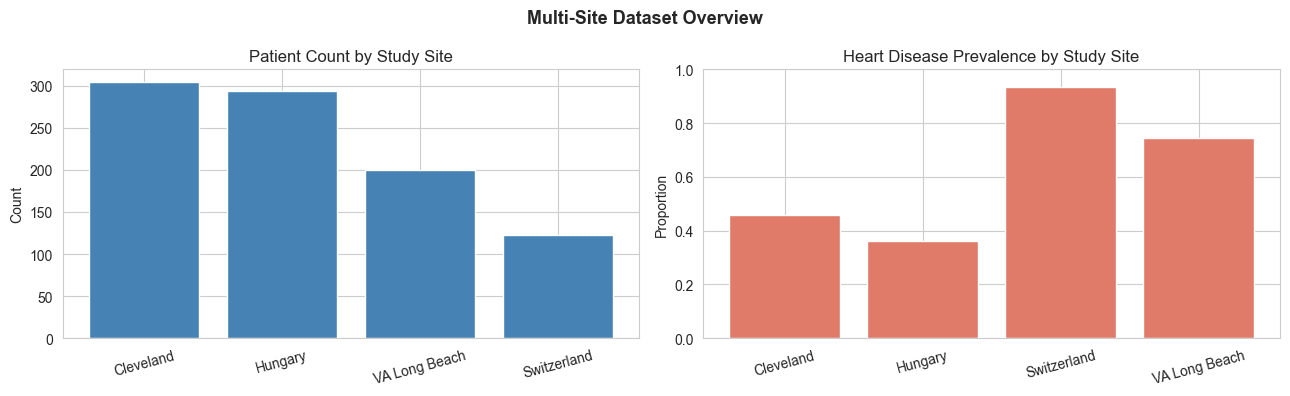

      dataset  Heart Disease Rate
    Cleveland            0.457237
      Hungary            0.361775
  Switzerland            0.934959
VA Long Beach            0.745000


In [5]:
# Data is drawn from four research sites; site-specific differences may affect generalisability.
site_counts = df_raw['dataset'].value_counts()
site_rate   = (
    df_raw.groupby('dataset')
          .apply(lambda x: (x['diagnosis'] > 0).mean())
          .reset_index(name='Heart Disease Rate')
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(site_counts.index, site_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Patient Count by Study Site')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(site_rate['dataset'], site_rate['Heart Disease Rate'], color='#E07B6A', edgecolor='white')
axes[1].set_title('Heart Disease Prevalence by Study Site')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=15)
axes[1].set_ylim(0, 1)

plt.suptitle('Multi-Site Dataset Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(site_rate.to_string(index=False))

### 2.3 Class Balance

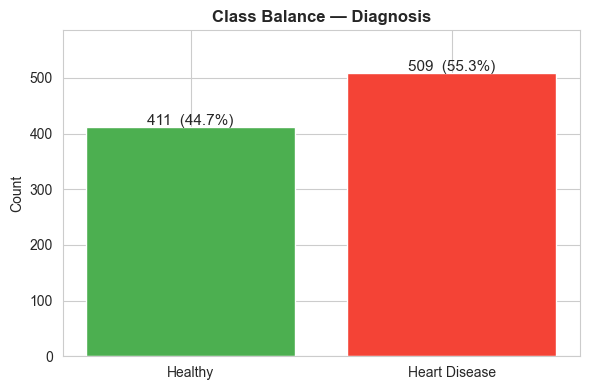

In [6]:
counts = df_clean[TARGET].value_counts().sort_index()
labels = ['Healthy', 'Heart Disease']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts.values, color=['#4CAF50', '#F44336'], edgecolor='white')
for bar, n in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4,
            f'{n}  ({n / len(df_clean) * 100:.1f}%)', ha='center', fontsize=11)
ax.set_title('Class Balance — Diagnosis', fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, max(counts.values) * 1.15)
plt.tight_layout()
plt.show()

### 2.4 Missing Value Analysis

,Count,Pct
st_slope,309,33.6
cholesterol,202,22.0
fbs,90,9.8
stress_st_depression,62,6.7
resting_bp,60,6.5
exercise_induced_angina,55,6.0
max_hr,55,6.0
rest_ecg,2,0.2


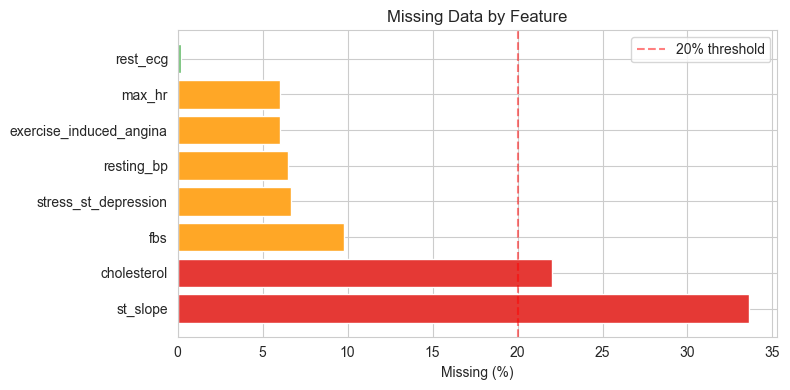

Note: st_slope exceeds 25% missingness — motivates the NO_SLOPE scenario.


In [7]:
missing = df_clean.isnull().sum()
missing_pct = (missing / len(df_clean) * 100).round(1)
missing_df = (
    pd.DataFrame({'Count': missing, 'Pct': missing_pct})
      .query('Count > 0')
      .sort_values('Pct', ascending=False)
)
display(missing_df)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#E53935' if p > 20 else '#FFA726' if p > 5 else '#66BB6A'
          for p in missing_df['Pct']]
ax.barh(missing_df.index, missing_df['Pct'], color=colors, edgecolor='white')
ax.axvline(20, color='red', linestyle='--', alpha=0.5, label='20% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Data by Feature')
ax.legend()
plt.tight_layout()
plt.show()

print("Note: st_slope exceeds 25% missingness — motivates the NO_SLOPE scenario.")

### 2.5 Feature Statistics by Diagnosis Group

In [8]:
numeric_features = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'stress_st_depression']
grouped = (
    df_clean.groupby(TARGET)[numeric_features]
            .agg(['mean', 'std'])
            .round(2)
)
grouped.index = ['Healthy (0)', 'Heart Disease (1)']
display(grouped)

age       resting_bp        cholesterol         max_hr  \
                    mean   std       mean    std        mean    std    mean   
Healthy (0)        50.55  9.43     129.91  16.87      240.16  55.77  148.80   
Heart Disease (1)  55.90  8.72     134.26  19.62      254.01  60.62  128.26   

                         stress_st_depression        
                     std                 mean   std  
Healthy (0)        23.61                 0.42  0.72  
Heart Disease (1)  24.02                 1.26  1.20

### 2.6 Numeric Feature Distributions by Diagnosis

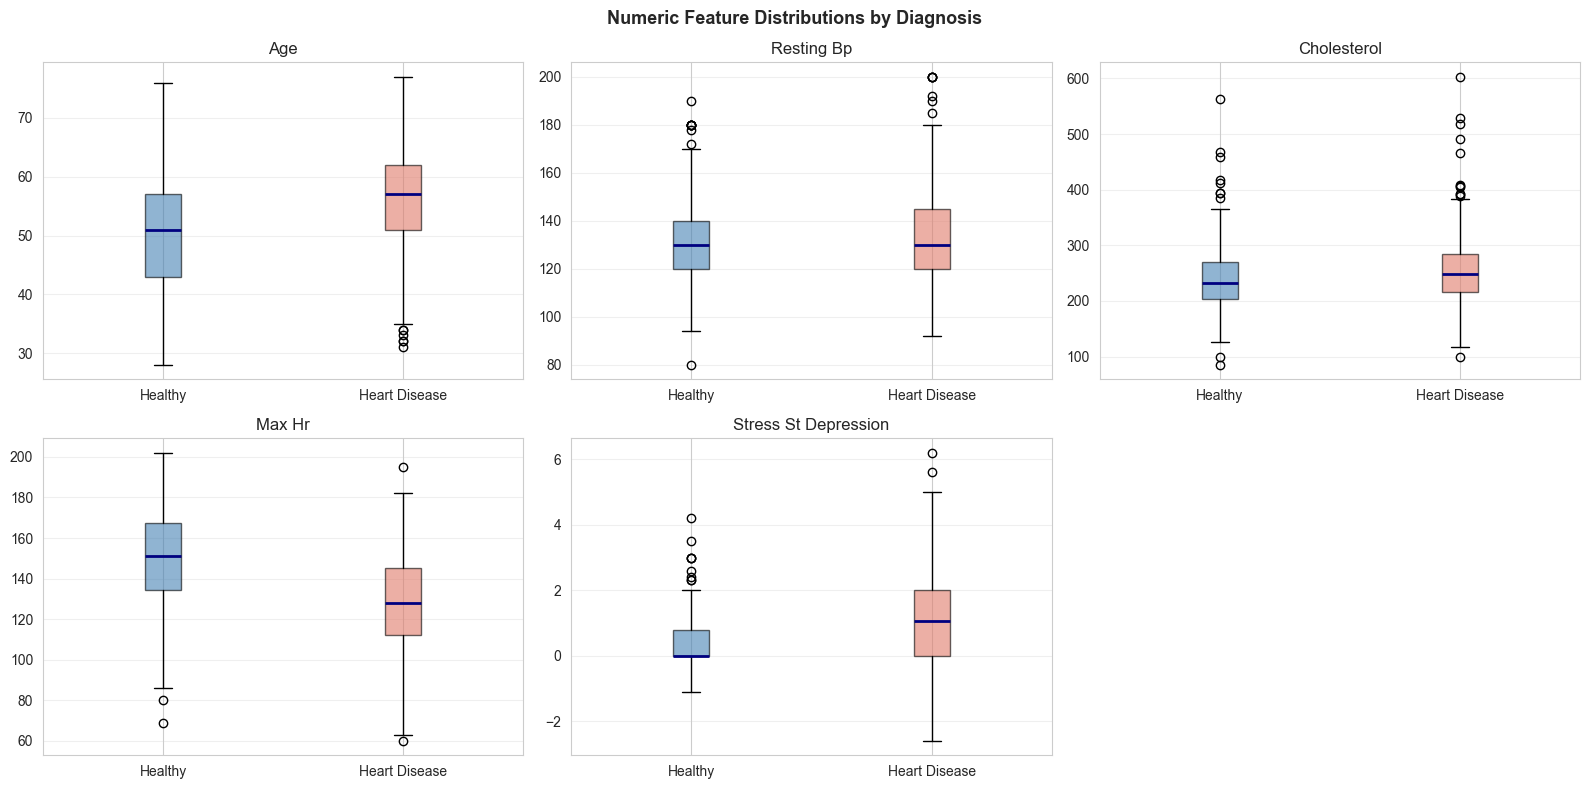

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    data = [df_clean.loc[df_clean[TARGET] == g, feat].dropna() for g in [0, 1]]
    bp = axes[i].boxplot(
        data, labels=['Healthy', 'Heart Disease'],
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.6),
        medianprops=dict(color='navy', linewidth=2)
    )
    bp['boxes'][1].set_facecolor('#E07B6A')
    axes[i].set_title(feat.replace('_', ' ').title())
    axes[i].grid(axis='y', alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('Numeric Feature Distributions by Diagnosis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.7 Correlation Analysis

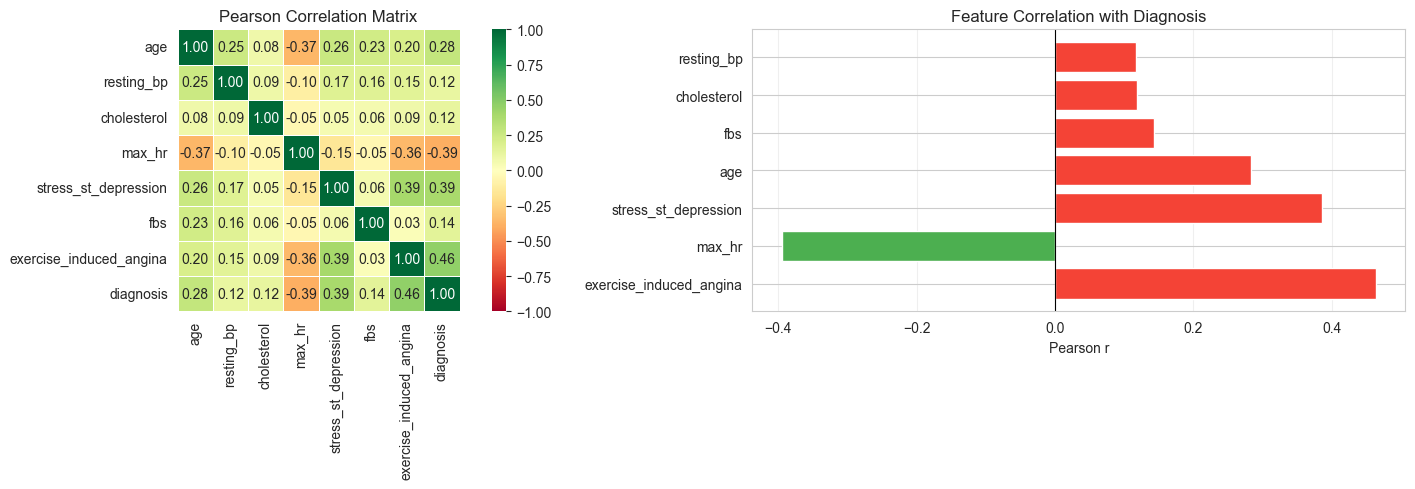

In [10]:
corr_cols = numeric_features + ['fbs', 'exercise_induced_angina', TARGET]
corr_matrix = df_clean[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Full correlation heatmap
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, ax=axes[0], square=True,
    linewidths=0.5
)
axes[0].set_title('Pearson Correlation Matrix')

# Feature correlation with diagnosis (ranked)
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
bar_colors  = ['#F44336' if c > 0 else '#4CAF50' for c in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=bar_colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with Diagnosis')
axes[1].set_xlabel('Pearson r')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 2.8 Categorical Feature Proportions by Diagnosis

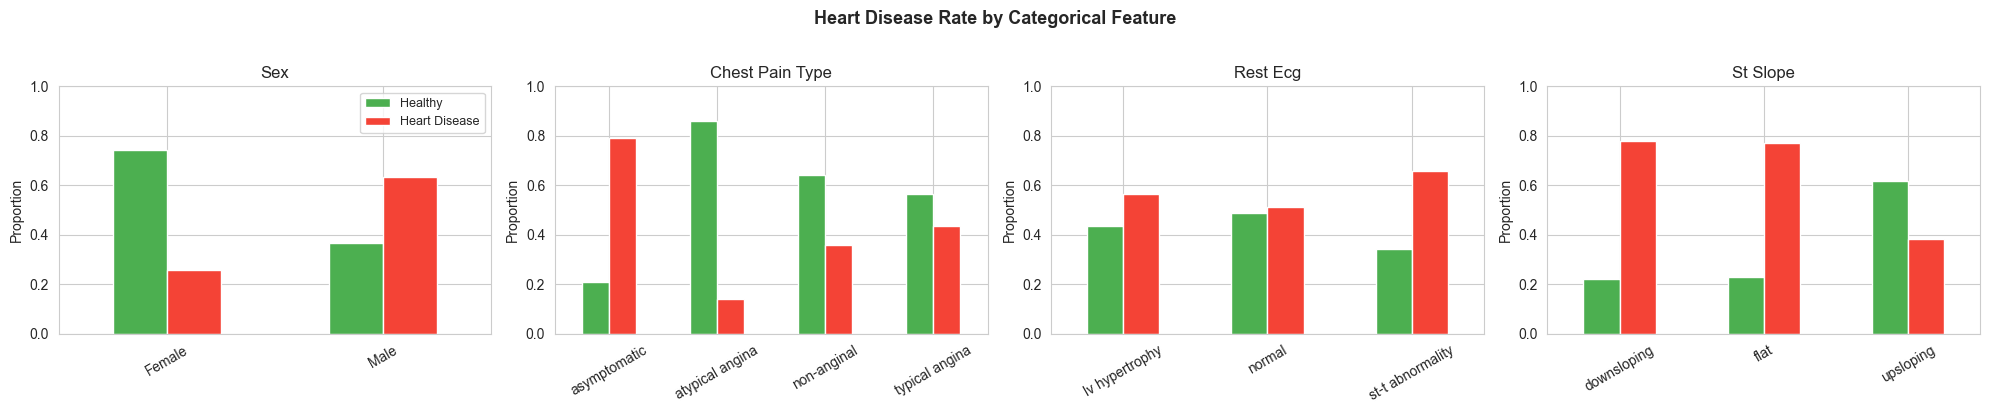

In [11]:
cat_features = ['sex', 'chest_pain_type', 'rest_ecg', 'st_slope']

fig, axes = plt.subplots(1, len(cat_features), figsize=(20, 4))

for ax, feat in zip(axes, cat_features):
    ct = df_clean.groupby([feat, TARGET]).size().unstack(fill_value=0)
    # Proportional bars show disease rate within each category
    ct_pct = ct.div(ct.sum(axis=1), axis=0)
    ct_pct.plot(kind='bar', ax=ax, color=['#4CAF50', '#F44336'],
                edgecolor='white', legend=False)
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.set_ylabel('Proportion')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylim(0, 1)

axes[0].legend(['Healthy', 'Heart Disease'], fontsize=9)
plt.suptitle('Heart Disease Rate by Categorical Feature', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Section 3: Leakage-Free Pipeline

Data is split before any imputation or scaling is applied.
Imputers and the standard scaler are fitted exclusively on the training set,
then applied to the test set — preventing test information from influencing training.

In [12]:
def build_pipeline(df, drop_slope=False, use_imputation=True, verbose=False):
    """
    Build a leakage-free train/test dataset.

    Parameters
    ----------
    drop_slope     : Remove st_slope before processing.
    use_imputation : Fit IterativeImputer/SimpleImputer on train only.
                     If False, rows with any missing value are dropped.
    verbose        : Log row counts at each step.

    Returns
    -------
    X_train_scaled, X_test_scaled, y_train, y_test,
    X_train_df (feature-named DataFrame for SHAP), df_test_raw
    """
    df_work = df.copy()

    if drop_slope:
        df_work = df_work.drop('st_slope', axis=1)

    if not use_imputation:
        n_before = len(df_work)
        df_work  = df_work.dropna()
        if verbose:
            print(f"  dropna: {n_before} -> {len(df_work)} rows retained")

    df_train_raw, df_test_raw = train_test_split(
        df_work, test_size=0.2, random_state=42, stratify=df_work[TARGET]
    )
    if verbose:
        print(f"  Split  | Train: {len(df_train_raw)}  Test: {len(df_test_raw)}")

    if use_imputation:
        imputers    = fit_imputers(df_train_raw)
        df_train_imp = apply_imputation(df_train_raw, imputers)
        df_test_imp  = apply_imputation(df_test_raw,  imputers)
    else:
        df_train_imp, df_test_imp = df_train_raw, df_test_raw

    df_train_enc = encode_categorical(df_train_imp)
    df_test_enc  = encode_categorical(df_test_imp)

    X_train = df_train_enc.drop(TARGET, axis=1)
    y_train = df_train_enc[TARGET]
    X_test  = df_test_enc.drop(TARGET, axis=1)
    y_test  = df_test_enc[TARGET]

    X_train_sc, X_test_sc, _ = scale_features(X_train, X_test)
    X_train_df = pd.DataFrame(X_train_sc, columns=X_train.columns)

    return X_train_sc, X_test_sc, y_train, y_test, X_train_df, df_test_raw

## Section 4: Scenario 1 — Full Impute

All features retained. IterativeImputer applied to numeric columns,
SimpleImputer (most frequent) applied to categorical columns.
This is the gold-standard scenario using the maximum available data.

In [13]:
print("Building pipeline: FULL IMPUTE")
df_s1 = clean_data(load_and_rename(DATA_PATH))
X_tr1, X_te1, y_tr1, y_te1, X_tr1_df, df_te1_raw = build_pipeline(
    df_s1, drop_slope=False, use_imputation=True, verbose=True
)

Building pipeline: FULL IMPUTE
  Split  | Train: 736  Test: 184


In [14]:
# Optuna tuning — each scenario is tuned independently for fairness.
# Note: N_TRIALS=100 per model; expect ~10-15 minutes per scenario.
print(f"Tuning (n_trials={N_TRIALS})...")
xgb_p1 = tune_xgboost(X_tr1, y_tr1, n_trials=N_TRIALS)
rf_p1  = tune_random_forest(X_tr1, y_tr1, n_trials=N_TRIALS)

Tuning (n_trials=100)...
Optimizing XGBoost (100 trials)...
Best ROC AUC: 0.8831
Optimizing Random Forest (100 trials)...
Best ROC AUC: 0.8816



LogisticRegression  (threshold=0.4)
  CV   | Prec: 0.823  Rec: 0.815  AUC: 0.875
  Test | Prec: 0.777  Rec: 0.853  Acc: 0.783  AUC: 0.896

  Classification Report (Test, threshold=0.4):
               precision    recall  f1-score   support

      Healthy       0.79      0.70      0.74        82
Heart Disease       0.78      0.85      0.81       102

     accuracy                           0.78       184
    macro avg       0.78      0.77      0.78       184
 weighted avg       0.78      0.78      0.78       184



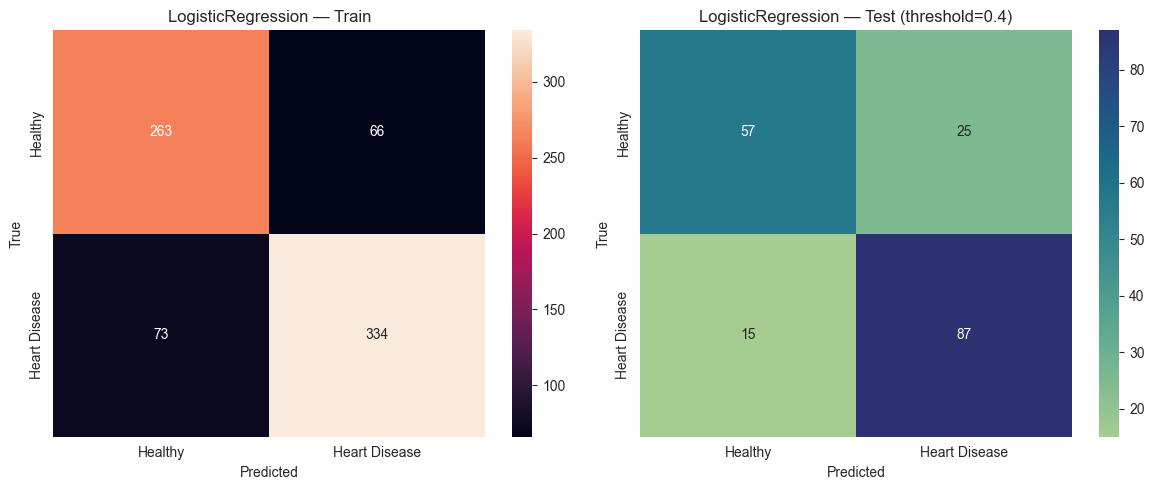


RandomForestClassifier  (threshold=0.4)
  CV   | Prec: 0.815  Rec: 0.870  AUC: 0.882
  Test | Prec: 0.760  Rec: 0.931  Acc: 0.799  AUC: 0.911

  Classification Report (Test, threshold=0.4):
               precision    recall  f1-score   support

      Healthy       0.88      0.63      0.74        82
Heart Disease       0.76      0.93      0.84       102

     accuracy                           0.80       184
    macro avg       0.82      0.78      0.79       184
 weighted avg       0.81      0.80      0.79       184



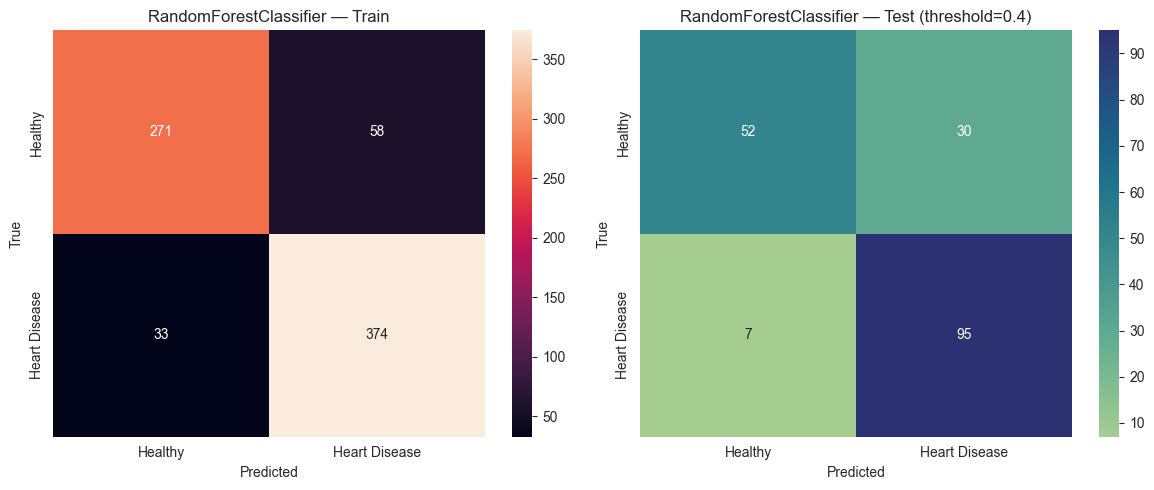


XGBClassifier  (threshold=0.4)
  CV   | Prec: 0.820  Rec: 0.860  AUC: 0.879
  Test | Prec: 0.772  Rec: 0.931  Acc: 0.810  AUC: 0.906

  Classification Report (Test, threshold=0.4):
               precision    recall  f1-score   support

      Healthy       0.89      0.66      0.76        82
Heart Disease       0.77      0.93      0.84       102

     accuracy                           0.81       184
    macro avg       0.83      0.79      0.80       184
 weighted avg       0.82      0.81      0.80       184



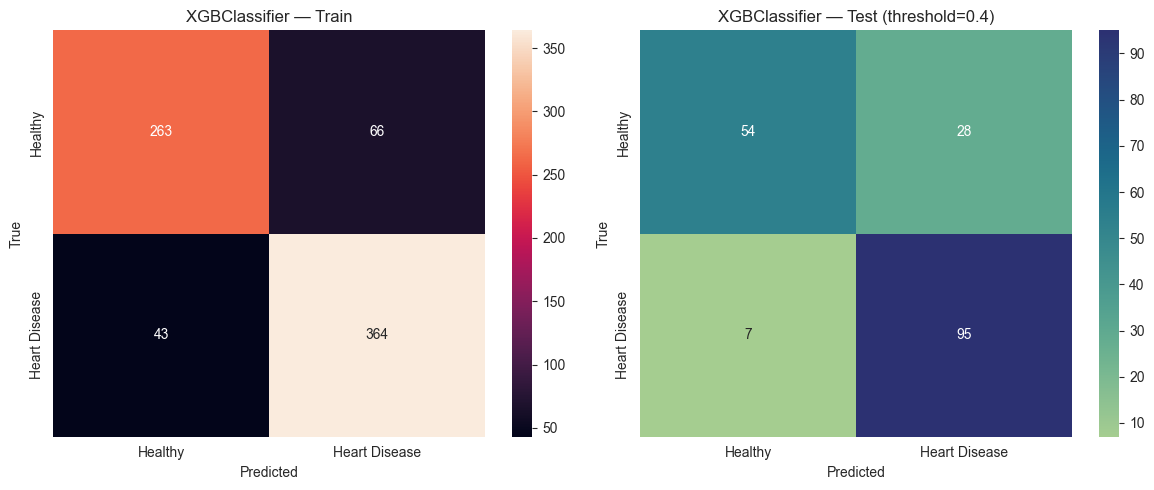

In [15]:
# class_weight='balanced' compensates for any class imbalance in LR.
lr_1  = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
rf_1  = RandomForestClassifier(**rf_p1)
xgb_1 = XGBClassifier(**xgb_p1)

m_lr_1  = evaluate_model(lr_1,  X_tr1, X_te1, y_tr1, y_te1, show_plots=True, threshold=THRESHOLD)
m_rf_1  = evaluate_model(rf_1,  X_tr1, X_te1, y_tr1, y_te1, show_plots=True, threshold=THRESHOLD)
m_xgb_1 = evaluate_model(xgb_1, X_tr1, X_te1, y_tr1, y_te1, show_plots=True, threshold=THRESHOLD)

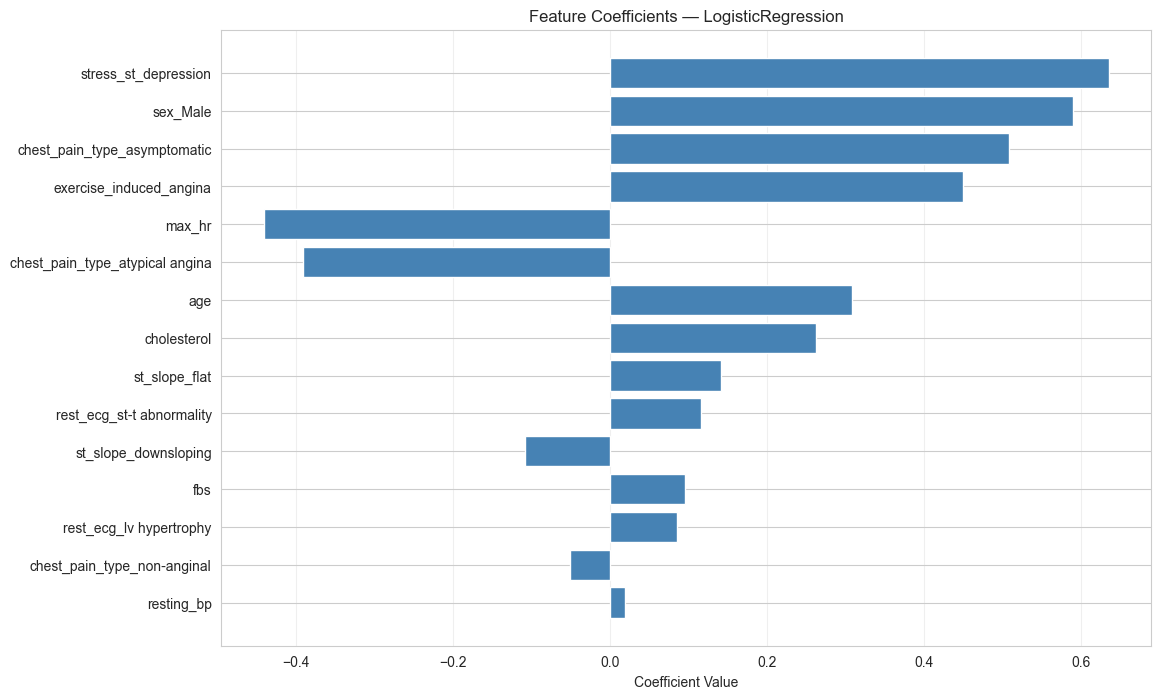

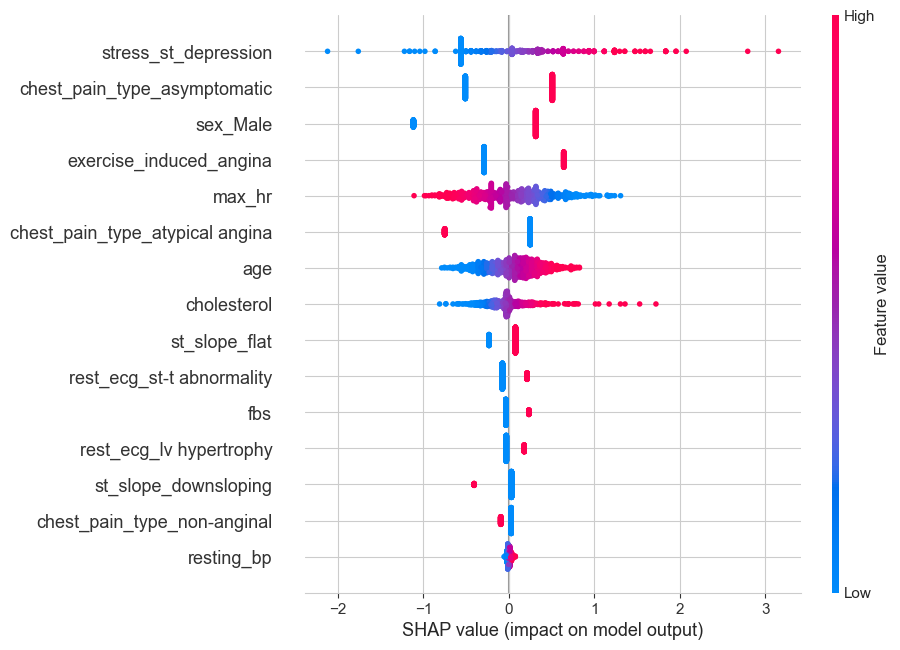

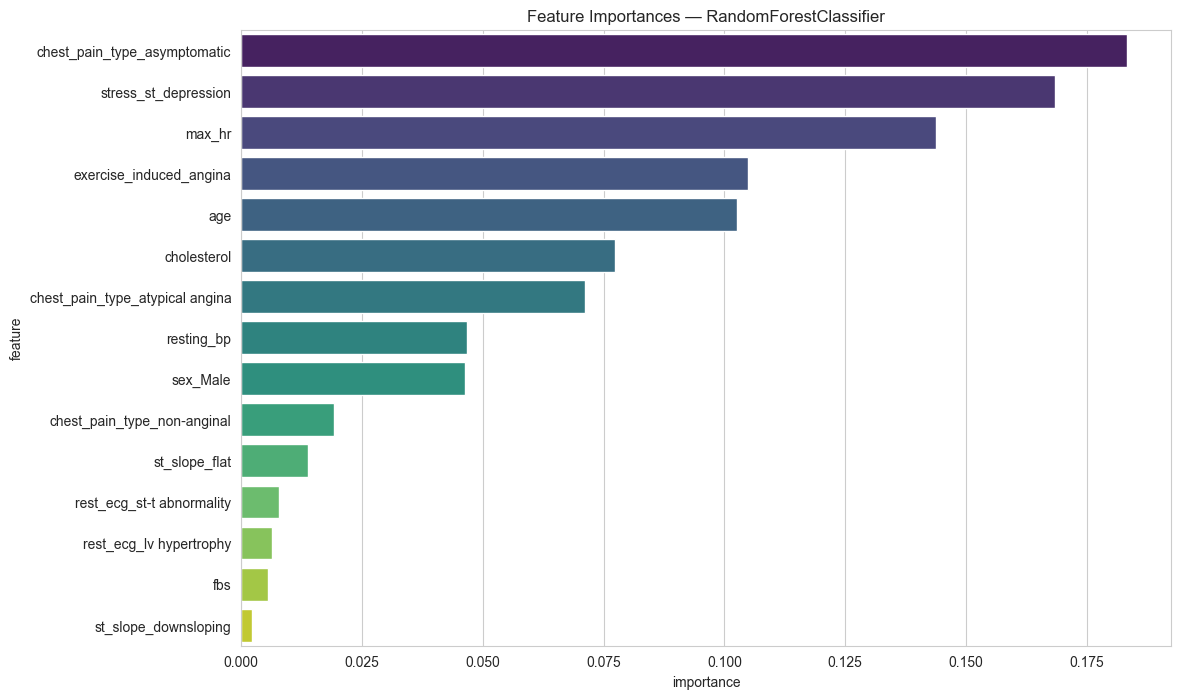

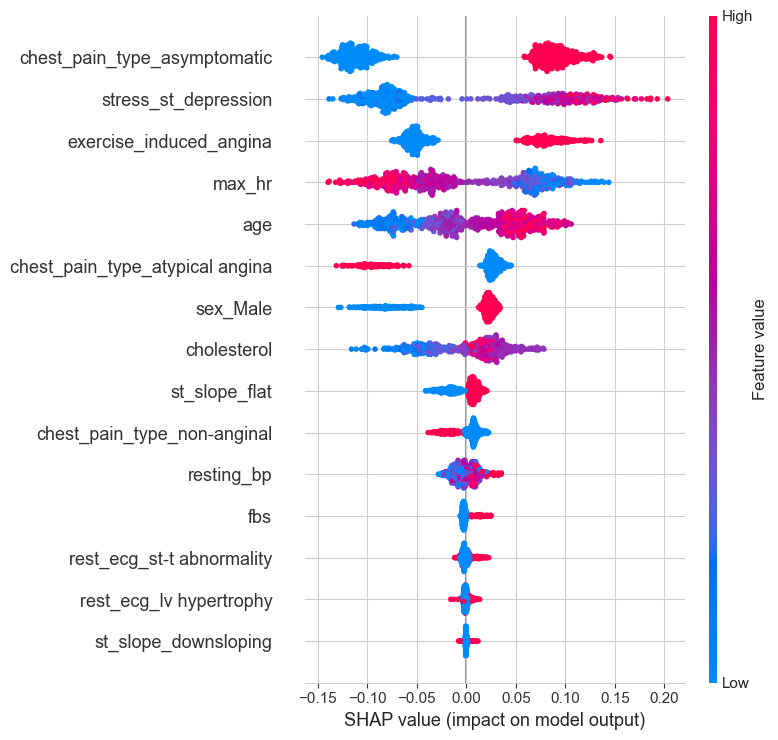

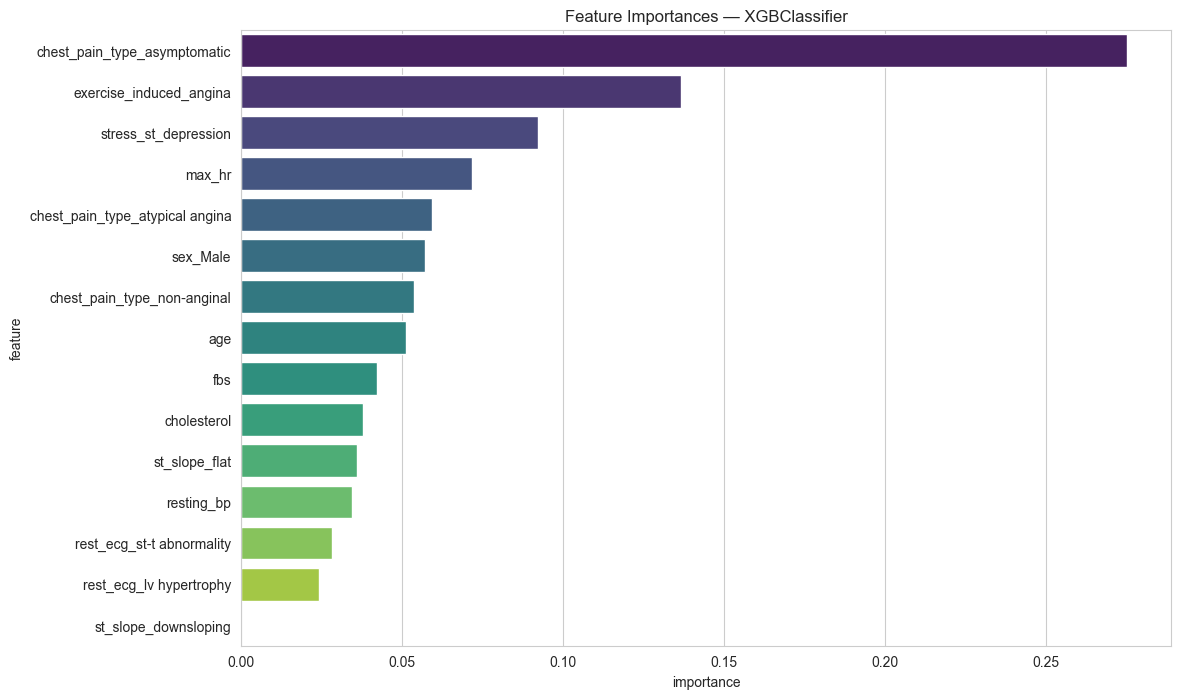

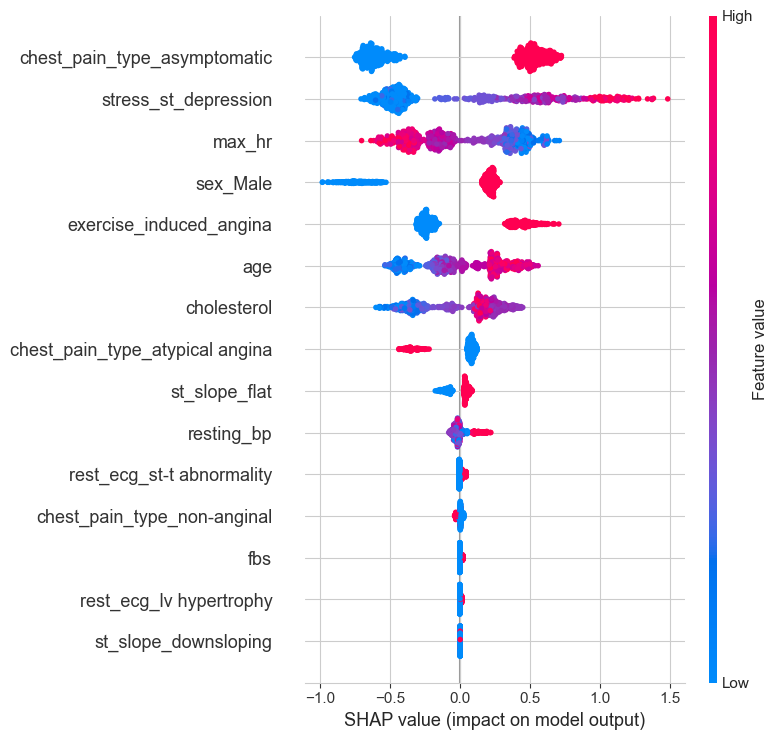

In [16]:
# Feature importance and SHAP — shown for all three models in Scenario 1.
plot_importance(lr_1,  X_tr1_df, show_plots=True)
plot_importance(rf_1,  X_tr1_df, show_plots=True)
plot_importance(xgb_1, X_tr1_df, show_plots=True)

## Section 5: Scenario 2 — No Slope, Impute

st_slope dropped (>25% missing). Imputation applied to remaining incomplete columns.
Simulates a clinical setting without ST-segment slope measurement.

In [17]:
print("Building pipeline: NO SLOPE + IMPUTE")
df_s2 = clean_data(load_and_rename(DATA_PATH))
X_tr2, X_te2, y_tr2, y_te2, X_tr2_df, df_te2_raw = build_pipeline(
    df_s2, drop_slope=True, use_imputation=True, verbose=True
)

print(f"\nTuning (n_trials={N_TRIALS})...")
xgb_p2 = tune_xgboost(X_tr2, y_tr2, n_trials=N_TRIALS)
rf_p2  = tune_random_forest(X_tr2, y_tr2, n_trials=N_TRIALS)

Building pipeline: NO SLOPE + IMPUTE
  Split  | Train: 736  Test: 184

Tuning (n_trials=100)...
Optimizing XGBoost (100 trials)...
Best ROC AUC: 0.8851
Optimizing Random Forest (100 trials)...
Best ROC AUC: 0.8826



LogisticRegression  (threshold=0.4)
  CV   | Prec: 0.821  Rec: 0.793  AUC: 0.877
  Test | Prec: 0.786  Rec: 0.863  Acc: 0.793  AUC: 0.898

  Classification Report (Test, threshold=0.4):
               precision    recall  f1-score   support

      Healthy       0.81      0.71      0.75        82
Heart Disease       0.79      0.86      0.82       102

     accuracy                           0.79       184
    macro avg       0.80      0.79      0.79       184
 weighted avg       0.79      0.79      0.79       184



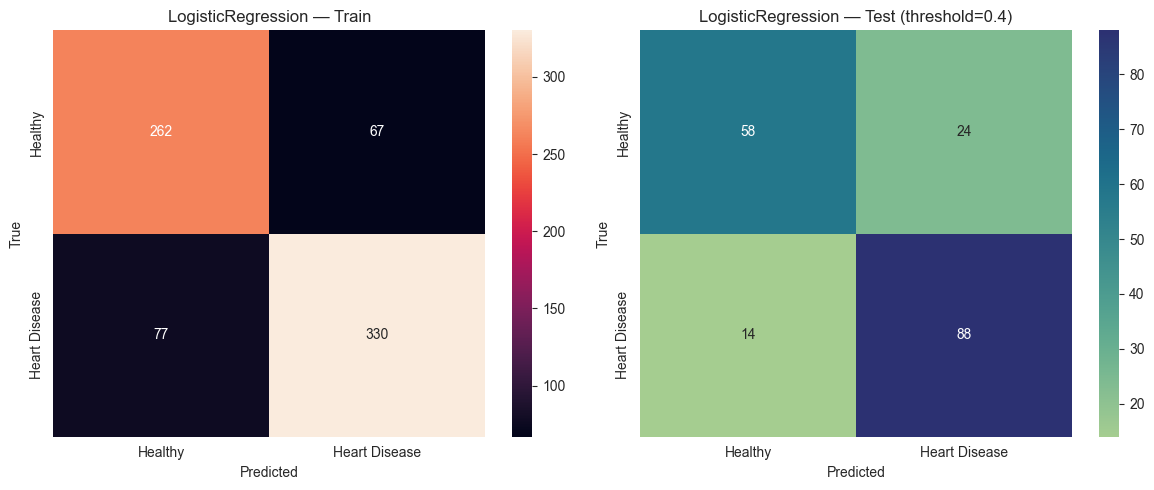


RandomForestClassifier  (threshold=0.4)
  CV   | Prec: 0.816  Rec: 0.875  AUC: 0.882
  Test | Prec: 0.754  Rec: 0.931  Acc: 0.793  AUC: 0.912

  Classification Report (Test, threshold=0.4):
               precision    recall  f1-score   support

      Healthy       0.88      0.62      0.73        82
Heart Disease       0.75      0.93      0.83       102

     accuracy                           0.79       184
    macro avg       0.82      0.78      0.78       184
 weighted avg       0.81      0.79      0.79       184



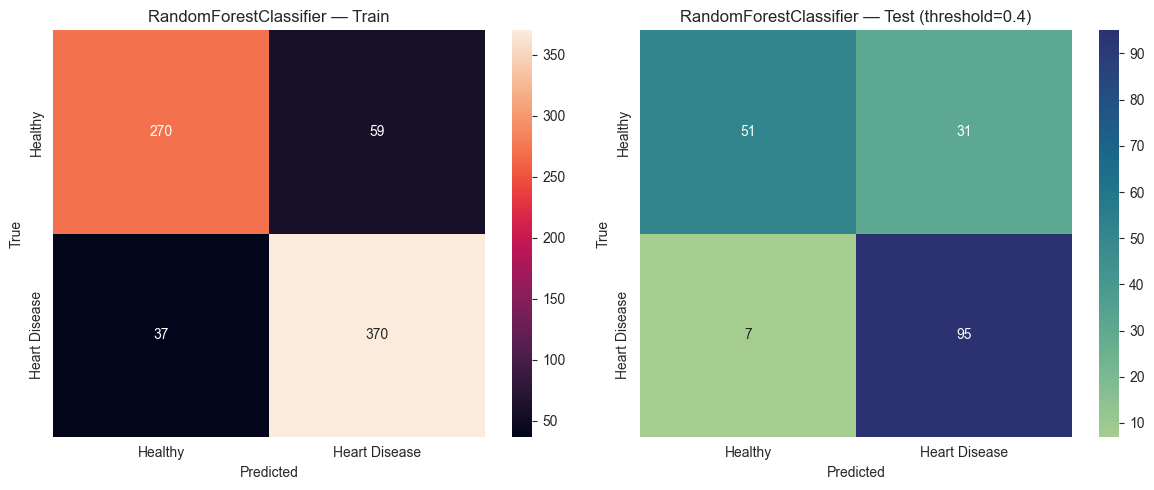


XGBClassifier  (threshold=0.4)
  CV   | Prec: 0.824  Rec: 0.857  AUC: 0.879
  Test | Prec: 0.766  Rec: 0.931  Acc: 0.804  AUC: 0.904

  Classification Report (Test, threshold=0.4):
               precision    recall  f1-score   support

      Healthy       0.88      0.65      0.75        82
Heart Disease       0.77      0.93      0.84       102

     accuracy                           0.80       184
    macro avg       0.82      0.79      0.79       184
 weighted avg       0.82      0.80      0.80       184



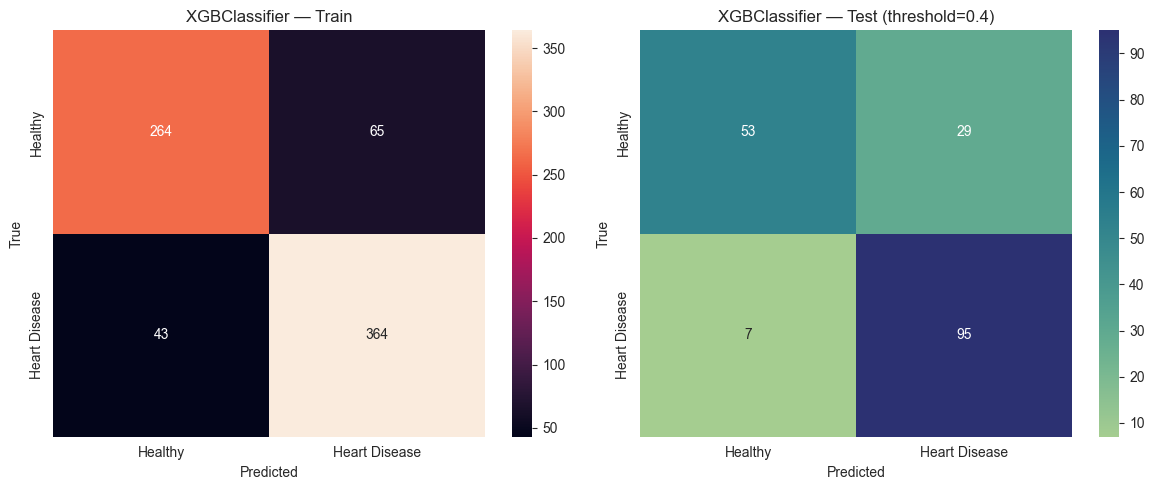

In [18]:
lr_2  = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
rf_2  = RandomForestClassifier(**rf_p2)
xgb_2 = XGBClassifier(**xgb_p2)

m_lr_2  = evaluate_model(lr_2,  X_tr2, X_te2, y_tr2, y_te2, show_plots=True, threshold=THRESHOLD)
m_rf_2  = evaluate_model(rf_2,  X_tr2, X_te2, y_tr2, y_te2, show_plots=True, threshold=THRESHOLD)
m_xgb_2 = evaluate_model(xgb_2, X_tr2, X_te2, y_tr2, y_te2, show_plots=True, threshold=THRESHOLD)

## Section 6: Scenario 3 — No Slope, No Impute

st_slope dropped. Remaining rows with any missing value are discarded.
Represents the traditional naive approach with no missing data handling.

In [19]:
print("Building pipeline: NO SLOPE + NO IMPUTE")
df_s3 = clean_data(load_and_rename(DATA_PATH))
X_tr3, X_te3, y_tr3, y_te3, X_tr3_df, df_te3_raw = build_pipeline(
    df_s3, drop_slope=True, use_imputation=False, verbose=True
)

print(f"\nTuning (n_trials={N_TRIALS})...")
xgb_p3 = tune_xgboost(X_tr3, y_tr3, n_trials=N_TRIALS)
rf_p3  = tune_random_forest(X_tr3, y_tr3, n_trials=N_TRIALS)

Building pipeline: NO SLOPE + NO IMPUTE
  dropna: 920 -> 661 rows retained
  Split  | Train: 528  Test: 133

Tuning (n_trials=100)...
Optimizing XGBoost (100 trials)...
Best ROC AUC: 0.8795
Optimizing Random Forest (100 trials)...
Best ROC AUC: 0.8785



LogisticRegression  (threshold=0.4)
  CV   | Prec: 0.795  Rec: 0.781  AUC: 0.885
  Test | Prec: 0.714  Rec: 0.873  Acc: 0.774  AUC: 0.906

  Classification Report (Test, threshold=0.4):
               precision    recall  f1-score   support

      Healthy       0.86      0.69      0.76        70
Heart Disease       0.71      0.87      0.79        63

     accuracy                           0.77       133
    macro avg       0.79      0.78      0.77       133
 weighted avg       0.79      0.77      0.77       133



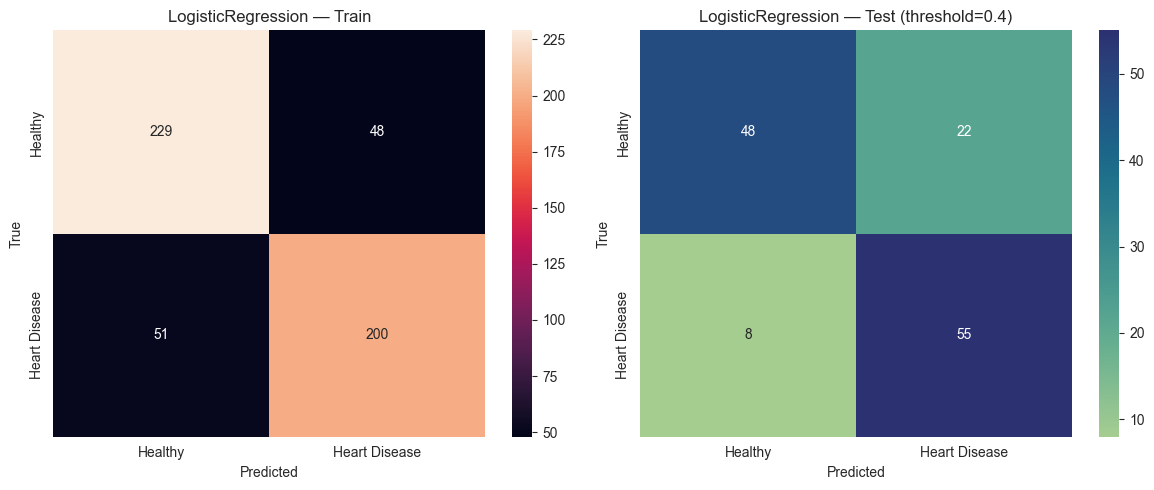


RandomForestClassifier  (threshold=0.4)
  CV   | Prec: 0.800  Rec: 0.749  AUC: 0.881
  Test | Prec: 0.747  Rec: 0.889  Acc: 0.805  AUC: 0.895

  Classification Report (Test, threshold=0.4):
               precision    recall  f1-score   support

      Healthy       0.88      0.73      0.80        70
Heart Disease       0.75      0.89      0.81        63

     accuracy                           0.80       133
    macro avg       0.81      0.81      0.80       133
 weighted avg       0.82      0.80      0.80       133



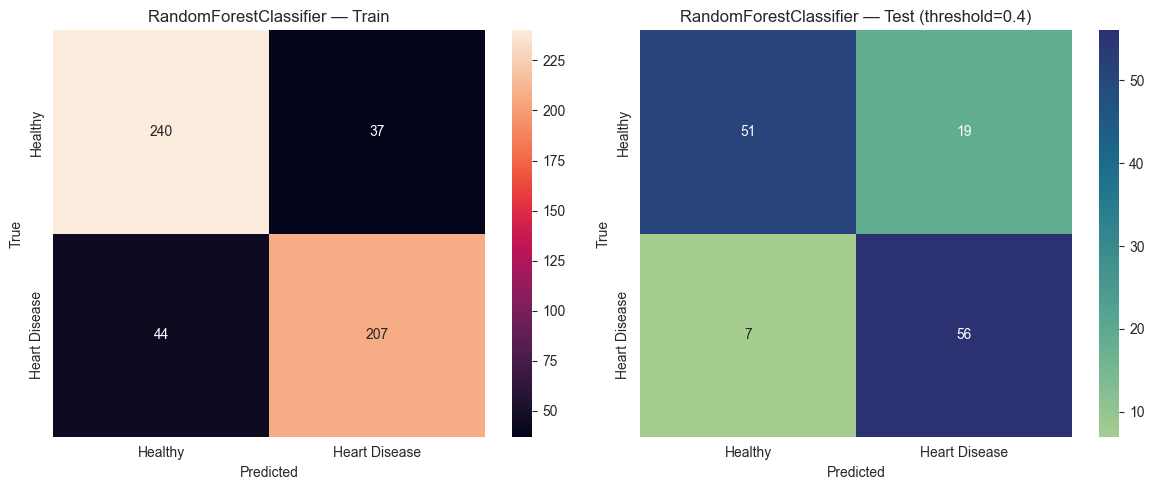


XGBClassifier  (threshold=0.4)
  CV   | Prec: 0.805  Rec: 0.757  AUC: 0.878
  Test | Prec: 0.764  Rec: 0.873  Acc: 0.812  AUC: 0.904

  Classification Report (Test, threshold=0.4):
               precision    recall  f1-score   support

      Healthy       0.87      0.76      0.81        70
Heart Disease       0.76      0.87      0.81        63

     accuracy                           0.81       133
    macro avg       0.82      0.82      0.81       133
 weighted avg       0.82      0.81      0.81       133



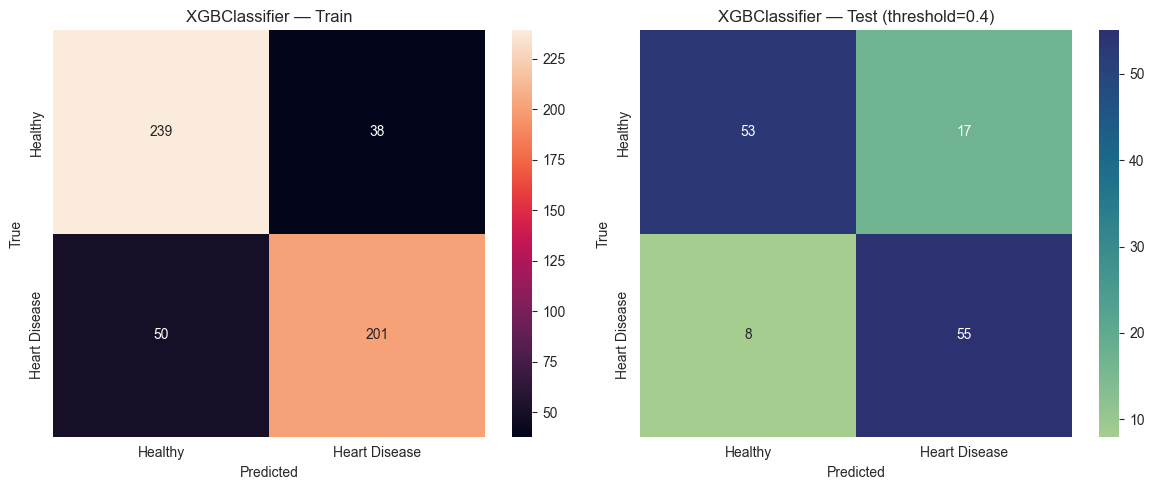

In [20]:
lr_3  = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
rf_3  = RandomForestClassifier(**rf_p3)
xgb_3 = XGBClassifier(**xgb_p3)

m_lr_3  = evaluate_model(lr_3,  X_tr3, X_te3, y_tr3, y_te3, show_plots=True, threshold=THRESHOLD)
m_rf_3  = evaluate_model(rf_3,  X_tr3, X_te3, y_tr3, y_te3, show_plots=True, threshold=THRESHOLD)
m_xgb_3 = evaluate_model(xgb_3, X_tr3, X_te3, y_tr3, y_te3, show_plots=True, threshold=THRESHOLD)

## Section 7: Clinical Threshold Analysis

The default classification threshold of 0.5 treats false negatives
and false positives equally. In a medical screening context, missing a true
heart disease case (false negative) is more costly than a false alarm.
Lowering the threshold to 0.4 improves Recall (sensitivity) at a moderate
cost to Precision.

In [21]:
# Threshold sweep using the best scenario model (XGB, Scenario 1)
probs_test = xgb_1.predict_proba(X_te1)[:, 1]

threshold_grid = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
rows = []
for t in threshold_grid:
    preds = (probs_test >= t).astype(int)
    rows.append({
        'Threshold':  t,
        'Precision':  round(precision_score(y_te1, preds, zero_division=0), 3),
        'Recall':     round(recall_score(y_te1, preds, zero_division=0), 3),
        'F1':         round(f1_score(y_te1, preds, zero_division=0), 3),
        'Accuracy':   round(accuracy_score(y_te1, preds), 3),
    })

threshold_df = pd.DataFrame(rows).set_index('Threshold')
display(threshold_df)

,Precision,Recall,F1,Accuracy
Threshold,,,,
0.30,0.746,0.951,0.836,0.793
0.35,0.756,0.941,0.838,0.799
0.40,0.772,0.931,0.844,0.810
0.45,0.773,0.902,0.833,0.799
0.50,0.791,0.853,0.821,0.793
0.55,0.796,0.843,0.819,0.793
0.60,0.844,0.794,0.818,0.804


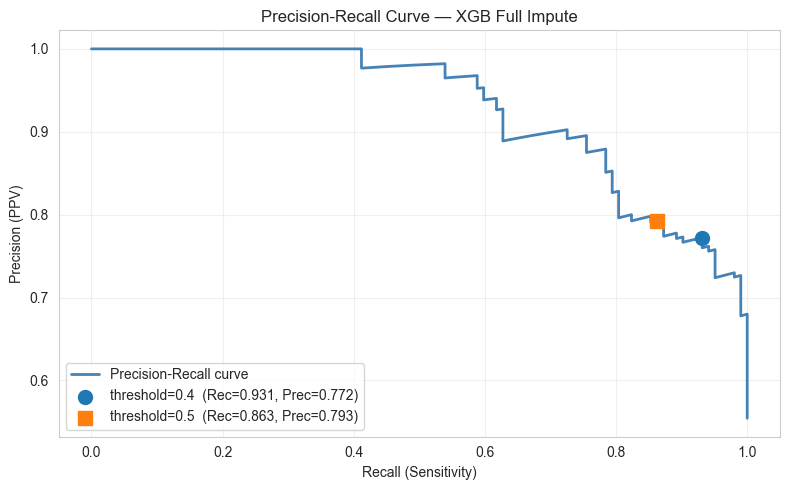

In [22]:
# Precision-recall curve with threshold markers
prec_vals, rec_vals, thresh_vals = precision_recall_curve(y_te1, probs_test)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec_vals, prec_vals, color='steelblue', linewidth=2, label='Precision-Recall curve')

# Mark selected thresholds
for t, marker, label in [(0.4, 'o', 'threshold=0.4'), (0.5, 's', 'threshold=0.5')]:
    idx = np.argmin(np.abs(thresh_vals - t))
    ax.scatter(rec_vals[idx], prec_vals[idx], s=100, zorder=5,
               label=f'{label}  (Rec={rec_vals[idx]:.3f}, Prec={prec_vals[idx]:.3f})',
               marker=marker)

ax.set_xlabel('Recall (Sensitivity)')
ax.set_ylabel('Precision (PPV)')
ax.set_title('Precision-Recall Curve — XGB Full Impute')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/precision_recall_curve.png', bbox_inches='tight', dpi=150)
plt.show()

## Section 8: Scientific Comparison Summary

All 9 combinations (3 scenarios x 3 models), each independently tuned.
CV ROC AUC is used as the primary ranking metric as it is stable across fold variation.
All test metrics are computed at threshold=0.4.

In [27]:
summary_data = [
    {'Scenario': 'FULL_IMPUTE',        'Model': 'LR',  **m_lr_1},
    {'Scenario': 'FULL_IMPUTE',        'Model': 'RF',  **m_rf_1},
    {'Scenario': 'FULL_IMPUTE',        'Model': 'XGB', **m_xgb_1},
    {'Scenario': 'NO_SLOPE_IMPUTE',    'Model': 'LR',  **m_lr_2},
    {'Scenario': 'NO_SLOPE_IMPUTE',    'Model': 'RF',  **m_rf_2},
    {'Scenario': 'NO_SLOPE_IMPUTE',    'Model': 'XGB', **m_xgb_2},
    {'Scenario': 'NO_SLOPE_NO_IMPUTE', 'Model': 'LR',  **m_lr_3},
    {'Scenario': 'NO_SLOPE_NO_IMPUTE', 'Model': 'RF',  **m_rf_3},
    {'Scenario': 'NO_SLOPE_NO_IMPUTE', 'Model': 'XGB', **m_xgb_3},
]

summary_df = (
    pd.DataFrame(summary_data)
      .rename(columns={
          'cv_roc_auc': 'CV ROC AUC',
          'roc_auc':    'Test ROC AUC',
          'precision':  'Test Precision',
          'recall':     'Test Recall',
          'accuracy':   'Test Accuracy'
      })
      .sort_values(['Test Recall', 'Test Precision', 'Test ROC AUC'], ascending=False)
      .reset_index(drop=True)
)

metric_cols = ['CV ROC AUC', 'Test ROC AUC', 'Test Precision', 'Test Recall', 'Test Accuracy']
summary_df[metric_cols] = summary_df[metric_cols].round(3)

display(summary_df[['Scenario', 'Model'] + metric_cols])

,Scenario,Model,CV ROC AUC,Test ROC AUC,Test Precision,Test Recall,Test Accuracy
0,FULL_IMPUTE,XGB,0.879,0.906,0.772,0.931,0.810
1,NO_SLOPE_IMPUTE,XGB,0.879,0.904,0.766,0.931,0.804
2,FULL_IMPUTE,RF,0.882,0.911,0.760,0.931,0.799
3,NO_SLOPE_IMPUTE,RF,0.882,0.912,0.754,0.931,0.793
4,NO_SLOPE_NO_IMPUTE,RF,0.881,0.895,0.747,0.889,0.805
5,NO_SLOPE_NO_IMPUTE,XGB,0.878,0.904,0.764,0.873,0.812
6,NO_SLOPE_NO_IMPUTE,LR,0.885,0.906,0.714,0.873,0.774
7,NO_SLOPE_IMPUTE,LR,0.877,0.898,0.786,0.863,0.793
8,FULL_IMPUTE,LR,0.875,0.896,0.777,0.853,0.783


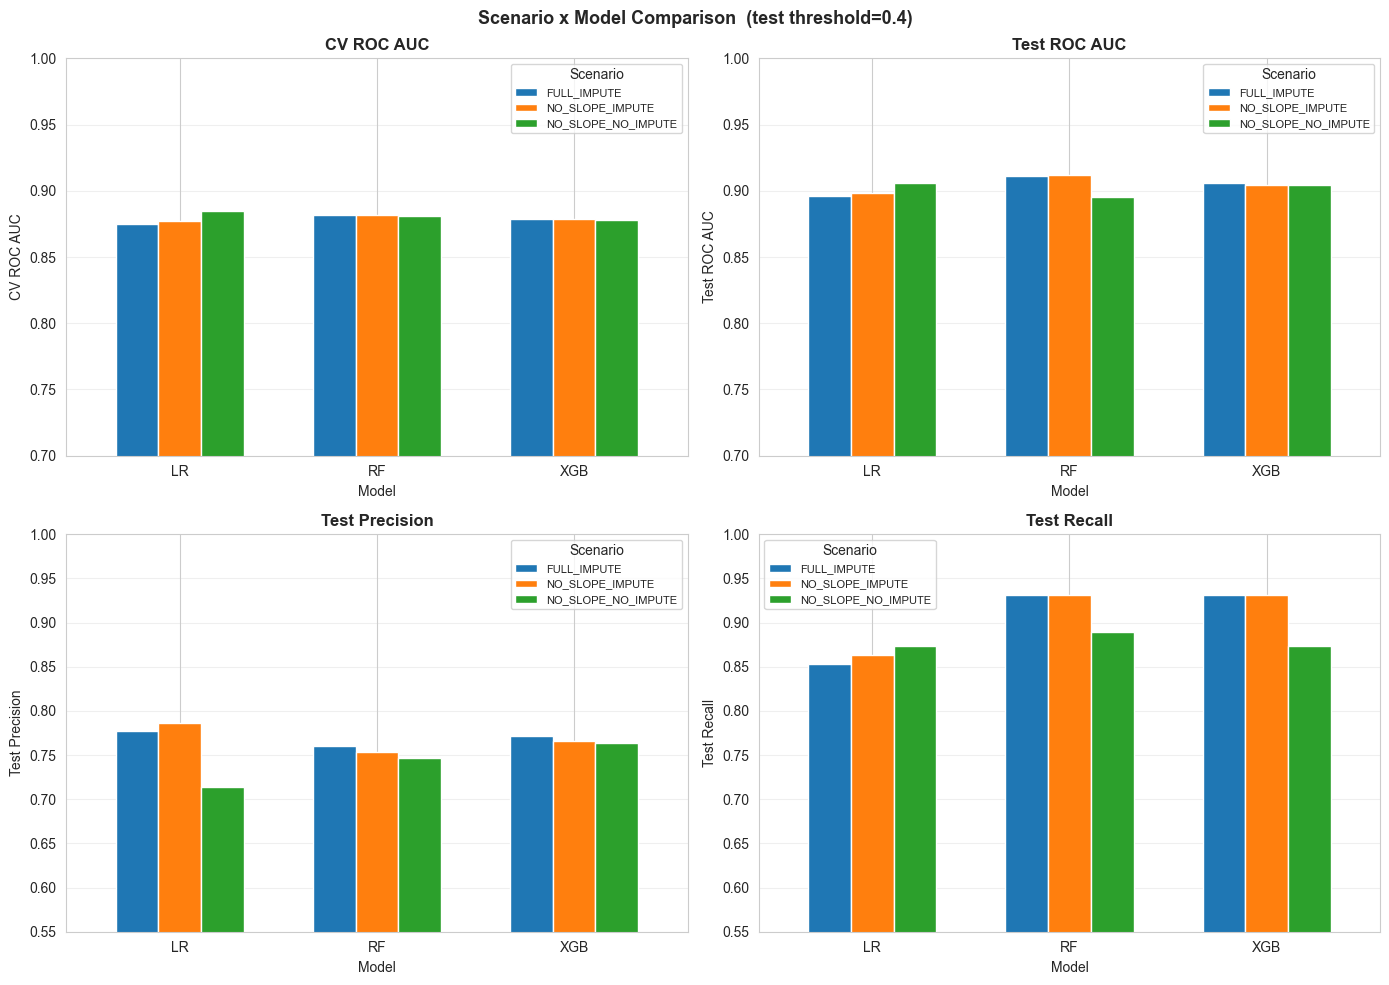

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_config = [
    (axes[0, 0], 'CV ROC AUC',     (0.70, 1.0)),
    (axes[0, 1], 'Test ROC AUC',   (0.70, 1.0)),
    (axes[1, 0], 'Test Precision',  (0.55, 1.0)),
    (axes[1, 1], 'Test Recall',     (0.55, 1.0)),
]

for ax, metric, ylim in plot_config:
    pivot = summary_df.pivot(index='Model', columns='Scenario', values=metric)
    pivot.plot(kind='bar', ax=ax, edgecolor='white', width=0.65)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(*ylim)
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=8, title='Scenario')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'Scenario x Model Comparison  (test threshold={THRESHOLD})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/scenario_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## Section 9: Mismatch Analysis

Patients in the FULL_IMPUTE test set where XGBoost produced an incorrect prediction.
These cases are worth investigating clinically — they may represent ambiguous presentations.

In [25]:
mismatches = get_mismatches(xgb_1, X_te1, y_te1.values, df_te1_raw, threshold=THRESHOLD)

if mismatches is not None:
    print(f"Mismatched predictions: {len(mismatches)} / {len(y_te1)} test patients")
    display(mismatches.head(10))
else:
    print("No mismatches — all test predictions correct.")

Mismatched predictions: 35 / 184 test patients


,age,sex,chest_pain_type,resting_bp,cholesterol,fbs,rest_ecg,max_hr,exercise_induced_angina,stress_st_depression,st_slope,diagnosis,predicted_diagnosis
514,49,Male,asymptomatic,130.0,206.0,0.0,normal,170.0,0.0,0.0,NaN,1,0
887,69,Male,non-anginal,NaN,271.0,0.0,lv hypertrophy,NaN,NaN,NaN,NaN,0,1
483,59,Male,non-anginal,130.0,318.0,0.0,normal,120.0,1.0,1.0,flat,0,1
273,71,Female,asymptomatic,112.0,149.0,0.0,normal,125.0,0.0,1.6,flat,0,1
278,57,Male,atypical angina,154.0,232.0,0.0,lv hypertrophy,164.0,0.0,0.0,upsloping,1,0
717,72,Male,non-anginal,160.0,NaN,NaN,lv hypertrophy,114.0,0.0,1.6,flat,0,1
194,68,Female,non-anginal,120.0,211.0,0.0,lv hypertrophy,115.0,0.0,1.5,flat,0,1
597,32,Male,typical angina,95.0,NaN,NaN,normal,127.0,0.0,0.7,upsloping,1,0
727,60,Male,non-anginal,180.0,NaN,0.0,st-t abnormality,140.0,1.0,1.5,flat,0,1
571,55,Male,typical angina,140.0,295.0,0.0,NaN,136.0,0.0,0.0,NaN,1,0


## Section 10: Recommendations and Next Steps

| Priority | Area | Action |
| :---: | :--- | :--- |
| 1 | **Overfitting** | RF and XGB train AUC near 1.0 — tune `max_features`, `reg_lambda` more aggressively |
| 2 | **Threshold** | Validate 0.4 against clinical cost estimates; consider F-beta scoring with beta>1 |
| 3 | **Calibration** | Apply `CalibratedClassifierCV` so predicted probabilities reflect true likelihoods |
| 4 | **Cross-site validation** | Train on Cleveland only, test on other sites — tests real-world generalisability |
| 5 | **Serialisation** | Save best model + scaler with joblib for reproducible deployment |

**Why `ca` and `thal` are excluded:**
Fluoroscopy (`ca`) and thalassemia stress test (`thal`) directly visualise coronary artery disease.
They are sub-diagnoses of the outcome variable, not upstream clinical predictors.
Including them constitutes target leakage and would produce artificially inflated performance
on data that no clinician would have prior to confirming the diagnosis.